# Sub-Bytes
This Notebook uses Linear regression to reverse traces from `sub_bytes`.
We collected the 1000 data access traces and used Linear Regression to reverse the secrets.
The secrets were choosen randombly between 1 and $2^{64}$


In the end `spysgx` was able to correctly reverse the secret from 1000/1000 (100%) of the traces.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
import pathlib
import pandas as pd
import numpy as np


FOLDER_PATH = pathlib.Path("..") / "traces" / "sub_bytes"
OUTPUT_PATH = pathlib.Path(".") / "sub_bytes.csv"

try: 
    # Try to load the CSV File
    df = pd.read_csv(OUTPUT_PATH)
except FileNotFoundError:
    # Get all trace files in FOLDER_PATH
    trace_files = list(FOLDER_PATH.glob("*.txt"))

    # Create a dataframe with the trace files

    # Create a list of lists
    # Each list is a row in the dataframe
    # The first column is the secret value (analysed from the filename)
    # The rest of the colums are the instruction addresse

    data = []
    max_len = 0
    for trace_file in trace_files:
        # Get the secret value from the filename

        secret = int(trace_file.stem.split("_")[1])
        # Read the trace file
        with open(trace_file, "r") as f:
            trace = [int(x, 16) for x in f.read().splitlines()]
        # Add the secret value and the trace to the list of lists
        max_len = max(max_len, len(trace))
        data.append([trace_file.name, secret] + trace)

    # Create the dataframe
    df = pd.DataFrame(data, columns=["trace_file", "secret"] + [f"mem{i}" for i in range(max_len)])

    df.to_csv(OUTPUT_PATH, index = False)


In [4]:
df.head()

,trace_file,secret,mem0,mem1,mem2,mem3,mem4,mem5,mem6,mem7,...,mem76,mem77,mem78,mem79,mem80,mem81,mem82,mem83,mem84,mem85
0,trace_10054330088175825702.txt,10054330088175825702,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276294,...,5670666,4276395,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
1,trace_10056620415931647098.txt,10056620415931647098,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276378,...,5670666,4276395,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
2,trace_10060927644926136588.txt,10060927644926136588,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276268,...,5670666,4276395,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
3,trace_10072603235305851034.txt,10072603235305851034,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276410,...,5670666,4276395,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
4,trace_10083516355250079193.txt,10083516355250079193,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276473,...,5670666,4276395,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680


## Visualization
We can see in the valley that we have exactly 8 memory access matching the 8 bytes.

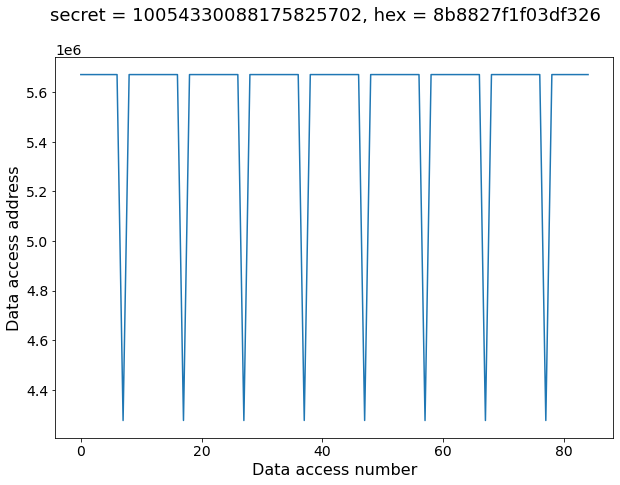

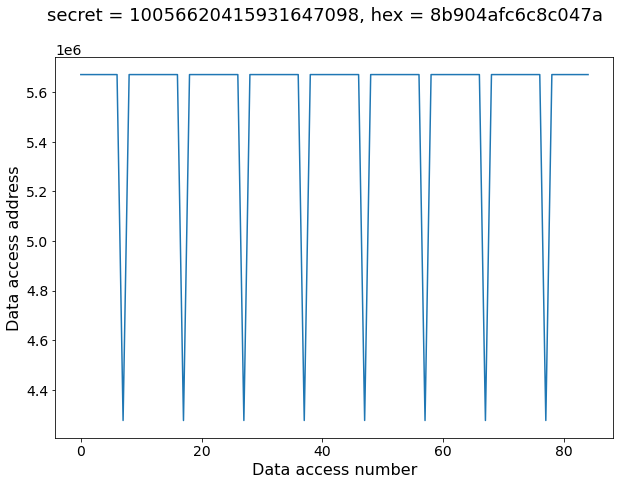

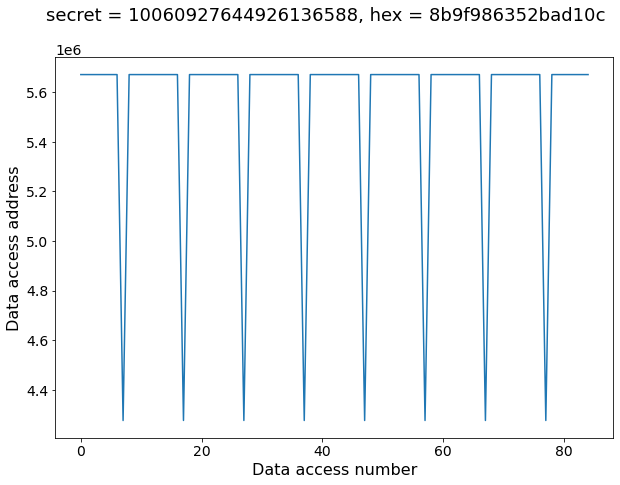

In [5]:
# Show example traces
with plt.style.context('./arend.mplstyle'):
    for i in range(3):
        _, secret, *traces = df.loc[i].to_list()[:-1]
        fig, ax = plt.subplots()
        ax.plot(traces)
        ax.set_xlabel("Data access number")
        ax.set_ylabel("Data access address")
        fig.suptitle(f"secret = {secret}, hex = {secret:08x}", size = 18)

# Reversing
We are using a Linear regression which will automatically find the relevant memory columns and add them together.

Linear regression internally works with float64, which would introduce rounding errors.
Therefore we split the Secret into the upper 32-bits and the lower 32-bits and join it together in the end

In [6]:
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values
y_lower = y % (1 << 32)
y_upper = (y >> 32) % (1 << 32)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Split target value in lower and upper bits
y_lower_train = y_train % (1 << 32)
y_upper_train = (y_train >> 32) % (1 << 32)

# Predict lower bits
regressor = LinearRegression()
regressor.fit(X_train, y_lower_train)
y_lower_pred = regressor.predict(X_test).round().astype(np.uint64)

# Predict upper bits
regressor = LinearRegression()
regressor.fit(X_train, y_upper_train)
y_upper_pred = regressor.predict(X_test).round().astype(np.uint64)

# Join together
y_pred = (y_upper_pred * (1 << 32)) + y_lower_pred


In [8]:
correct = sum(y_pred == y_test)/len(y_test)
print(f"{correct * 100:.02f} Percent of the secrets were reversed correctly")

100.00 Percent of the secrets were reversed correctly


## Symbolic execution
The results are in subBytes_results.csv (and took around 20hours lol)

In [39]:
df = pd.read_csv("subBytes_result.csv", header=None)

df.columns = ["filename", "result"]
df.head(n = 10)

,filename,result
0,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9009367547913688047
1,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,11478698587092284929
2,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,1438066405921618580
3,/home/goreil/spysgx/traces/sub_bytes_1/trace_4...,4424664326549472796
4,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,16802199084700449176
5,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,14574058148577264727
6,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9466134467976816724
7,/home/goreil/spysgx/traces/sub_bytes_1/trace_8...,8594594829896249617
8,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9219329541772945041
9,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9338674384430385556


In [42]:
df['secret'] = df.filename.str[45:-4]
df = df.astype({"secret": "uint64"})
df.head()

,filename,result,secret
0,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9009367547913688047,9009367547913688047
1,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,11478698587092284929,11478698587092284929
2,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,1438066405921618580,1438066405921618580
3,/home/goreil/spysgx/traces/sub_bytes_1/trace_4...,4424664326549472796,4424664326549472796
4,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,16802199084700449176,16802199084700449176


In [47]:
correct = sum(df.result == df.secret)/len(df)
print(f"{correct * 100:.02f} Percent of the secrets were reversed correctly")

100.00 Percent of the secrets were reversed correctly
